# HapSleep — POC 1: motor de ML para riesgo de mala calidad de sueño

**Tesis:** app que predice el riesgo de mala calidad de sueño en estudiantes universitarios de Lima
usando datos de smartwatch, con un LLM que genera recomendaciones a partir de ese riesgo.
Este notebook es **ML1** (antes "C2" en versiones viejas del diseño): el modelo que clasifica
el nivel de riesgo de la **persona** (no de una noche puntual) y calcula qué factores lo explican.

**Dataset:** [LifeSnaps](https://zenodo.org/records/7229547) (Fitbit Sense, *Nature Scientific Data* 2022),
n=71 estudiantes/personas reales, 7,410 filas día-persona. Es el mismo dataset ya usado en el
análisis de autocorrelación/estabilidad de la tesis (r=0.727: el riesgo es un rasgo estable de la
persona, no de una noche — por eso todo el feature engineering agrega datos por persona).


**Este notebook es una versión limpia y documentada de `poc1/`** (mismo pipeline, mismos
hiperparámetros, mismos resultados) — pensada para mostrarle al asesor. La documentación técnica
completa, con más detalle y contexto de literatura, está en
[`poc1/README.md`](../../poc1/README.md) y [`poc1/FINDINGS_POC1.md`](../../poc1/FINDINGS_POC1.md).


## ⚠️ Antes de leer resultados — 2 cosas que hay que tener presentes

1. **La etiqueta de riesgo es un PROXY, no la etiqueta real.** LifeSnaps no incluye el
   cuestionario PSQI (el estándar clínico de calidad de sueño autorreportada). Se usa el
   puntaje de sueño que calcula el propio Fitbit (`sleep_points_percentage`) — el 25% más bajo
   se marca como "riesgo alto". Cuando existan los datos reales de la encuesta PSQI de la tesis
   (Capa A, n≥50), hay que reemplazar la etiqueta y volver a correr todo esto. **Los resultados
   de este notebook no son el resultado final para el TI.**
2. **n=71 es chico**, y por eso cada métrica se reporta como **media ± desviación estándar sobre
   20 repeticiones** de un 5-Fold estratificado, no como un solo número. Se comprobó
   empíricamente que un solo 5-Fold con esta n varía muchísimo según qué persona cae en qué
   fold (el F1 osciló entre 0.29 y 0.61 en 20 corridas de prueba con la misma configuración).


In [16]:
import json
import sys
import warnings
from pathlib import Path

try:
    sys.stdout.reconfigure(encoding="utf-8")  # consola de Windows por defecto usa cp1252, truena con tildes
except AttributeError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, average_precision_score,
)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110


## Configuración

Estas son las únicas constantes que definen el experimento. Mismos valores que el pipeline
oficial en `poc1/poc_c2_random_forest.py` — no se cambió nada aquí.

In [17]:
DATA_PATH = Path("data/daily_fitbit_sema_df_unprocessed.csv")

COL_ID = "id"
RANDOM_STATE = 42
N_FOLDS = 5          # Stratified K-Fold (n=71 -> ~14 personas por fold)
N_REPEATS = 20       # se repite el 5-Fold con 20 semillas distintas y se promedia
RISK_LABEL_QUANTILE = 0.25  # bottom 25% de calidad de sueño = "riesgo alto"

FEATURE_COLUMNS_PHYSIO = [
    "rmssd", "nremhr", "resting_hr", "spo2", "full_sleep_breathing_rate",
    "minutesToFallAsleep", "minutesAsleep", "minutesAwake",
    "sleep_efficiency", "sleep_points_percentage",
]
FEATURE_COLUMNS_BEHAVIORAL = ["steps", "sedentary_minutes"]
ALL_RAW_COLUMNS = FEATURE_COLUMNS_PHYSIO + FEATURE_COLUMNS_BEHAVIORAL


## 1. Carga de datos

El CSV trae columnas numéricas guardadas como texto en algunos participantes (valores faltantes
como `'nan'` literal) — se fuerza a numérico y se deja `NaN` donde no se pueda convertir.

In [18]:
def load_data() -> pd.DataFrame:
    if not DATA_PATH.exists():
        raise FileNotFoundError(f"No encuentro {DATA_PATH}. Revisa data/README o la ruta.")
    df = pd.read_csv(DATA_PATH)
    for col in ALL_RAW_COLUMNS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
        else:
            print(f"[!] Columna '{col}' no está en el CSV — se omite esa feature.")
    return df


raw_df = load_data()
print(f"Filas día-persona: {len(raw_df)} | personas únicas: {raw_df[COL_ID].nunique()}")
raw_df[ALL_RAW_COLUMNS].describe().T[["count", "mean", "std"]]


Filas día-persona: 7410 | personas únicas: 71


,count,mean,std
rmssd,2475.0,40.021232,21.305442
nremhr,2475.0,62.714134,11.051482
resting_hr,4422.0,66.268735,7.234891
spo2,1270.0,95.893228,1.114339
full_sleep_breathing_rate,2495.0,14.836954,3.774846
minutesToFallAsleep,3551.0,0.116305,2.515471
minutesAsleep,3551.0,393.071529,98.382524
minutesAwake,3551.0,56.625458,23.066553
sleep_efficiency,3551.0,93.776401,6.296757
sleep_points_percentage,1876.0,0.653998,0.303243


## 2. Feature engineering — agregación a nivel de persona

Cada feature fisiológica/conductual se agrega como **media** y **desviación estándar** por
persona a lo largo de sus días con datos. El `std` de `minutesAsleep` se renombra a
`sleep_duration_inconsistency` porque es explícitamente una de las variables de diseño de la
tesis (qué tan inconsistente es el sueño de esa persona noche a noche).

Los `NaN` aislados (persona con un solo día de datos, sin desviación estándar posible) se
imputan con la mediana poblacional de esa feature — está documentado como limitación, no es
ideal, pero evita que el pipeline truene con n tan chica.

In [19]:
def engineer_features(df: pd.DataFrame):
    present_cols = [c for c in ALL_RAW_COLUMNS if c in df.columns]

    agg = df.groupby(COL_ID)[present_cols].agg(["mean", "std"])
    agg.columns = [f"{col}_{stat}" for col, stat in agg.columns]
    agg = agg.reset_index()

    if "minutesAsleep_std" in agg.columns:
        agg = agg.rename(columns={"minutesAsleep_std": "sleep_duration_inconsistency"})

    agg = agg.dropna(subset=[c for c in agg.columns if c != COL_ID], how="all")
    feature_cols = [c for c in agg.columns if c != COL_ID]
    agg[feature_cols] = agg[feature_cols].fillna(agg[feature_cols].median())
    return agg, feature_cols


person_df, feature_cols = engineer_features(raw_df)
print(f"n personas (con datos suficientes) = {len(person_df)} | features agregadas = {len(feature_cols)}")
person_df.head()


n personas (con datos suficientes) = 71 | features agregadas = 24


,id,rmssd_mean,rmssd_std,nremhr_mean,nremhr_std,resting_hr_mean,resting_hr_std,spo2_mean,spo2_std,full_sleep_breathing_rate_mean,...,minutesAwake_mean,minutesAwake_std,sleep_efficiency_mean,sleep_efficiency_std,sleep_points_percentage_mean,sleep_points_percentage_std,steps_mean,steps_std,sedentary_minutes_mean,sedentary_minutes_std
0,621e2e8e67b776a24055b564,100.410210,9.402428,56.571484,2.766234,59.897641,1.936963,95.954195,0.903931,15.270968,...,83.460317,15.108025,93.238095,2.005752,0.795767,0.106507,9167.085714,3384.097986,742.309859,202.624254
1,621e2eaf67b776a2406b14ac,25.992988,6.103989,68.988272,8.843768,69.418199,3.109986,95.954195,0.903931,14.767500,...,56.349398,17.318701,94.144578,2.696577,0.742683,0.225243,16790.500000,5973.028379,588.909091,185.741548
2,621e2ed667b776a24085d8d1,26.519625,7.926298,72.814016,5.600547,75.643610,3.476818,95.954195,0.903931,17.680000,...,60.802632,18.598939,95.000000,3.405877,0.619556,0.293107,4787.034884,2616.982198,980.991228,319.013454
3,621e2ef567b776a24099f889,36.265407,7.033274,62.361852,5.178568,60.122684,1.890932,97.700000,0.903931,14.715556,...,57.000000,18.607322,95.000000,2.587413,0.619556,0.293107,5538.500000,4842.354770,1408.255102,95.104642
4,621e2efa67b776a2409dd1c3,36.265407,7.033274,62.361852,5.178568,70.246620,3.587303,95.971212,0.972034,14.715556,...,67.606061,19.035900,93.136364,2.541268,0.619556,0.293107,7412.682927,4858.421862,1047.313869,378.120638


## 3. Etiqueta de riesgo (proxy) — y el chequeo de fuga de datos

**Fuga de datos (data leakage):** la columna cruda usada para construir la etiqueta (y TODAS sus
variantes `_mean`/`_std`) se excluye de las features de entrada. Esto ya causó dos fugas reales
durante la construcción de `poc1` (documentadas en `poc1/README.md`, sección de limitaciones,
punto 5) — dejar el `_mean` inflaba el resultado de forma circular, y dejar solo el `_std`
después de sacar el `_mean` seguía siendo fuga porque ambas vienen de la misma medición.

Cuando conectes el PSQI real, esta fuga específica no puede repetirse (es una encuesta,
100% independiente del wearable) — pero vale la pena repetir siempre el mismo chequeo.

In [20]:
def build_risk_label(person_df: pd.DataFrame):
    quality_col = "sleep_points_percentage_mean"
    if quality_col not in person_df.columns:
        raise ValueError("No encontré la columna para construir la etiqueta proxy.")
    threshold = person_df[quality_col].quantile(RISK_LABEL_QUANTILE)
    y = (person_df[quality_col] <= threshold).astype(int)
    raw_source_name = quality_col.rsplit("_", 1)[0]
    return y, raw_source_name


y, label_source_raw = build_risk_label(person_df)

# excluye TODAS las variantes agregadas de la columna cruda usada para la etiqueta
feature_cols = [c for c in feature_cols if not c.startswith(label_source_raw + "_")]
X = person_df[feature_cols]

print(f"Features de entrada tras excluir la fuga: {len(feature_cols)}")
print(f"Prevalencia de 'riesgo alto' (proxy): {y.mean():.1%}")


Features de entrada tras excluir la fuga: 22
Prevalencia de 'riesgo alto' (proxy): 25.4%


## 4. Metodología de evaluación

**Por qué Repeated Stratified K-Fold y no un solo split:** con n=71, un solo 5-Fold
(una sola asignación al azar de qué persona cae en qué fold) tiene varianza enorme — se probó
y el F1 de una sola corrida osciló entre 0.29 y 0.61 solo por la semilla del split. Por eso se
repite el 5-Fold con 20 semillas distintas y se reporta **media ± desviación estándar**, no un
solo número — igual de importante que nunca reportar accuracy pelada con clases desbalanceadas.

`evaluate_model` es genérico: recibe una función que construye el modelo y corre exactamente
la misma evaluación para cualquier clasificador de sklearn/xgboost, así los cuatro modelos de
abajo se comparan en igualdad de condiciones.

In [21]:
def compute_metrics(y_true, y_pred, y_proba):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }


def evaluate_model(model_factory, X, y, n_repeats=N_REPEATS):
    # OJO: el modelo se construye con una semilla FIJA (RANDOM_STATE) en cada
    # repeticion -- lo unico que cambia entre repeticiones es el split del
    # StratifiedKFold. Es el mismo criterio que poc1/poc_c2_random_forest.py
    # y poc1/poc_c2_model_comparison.py: la variabilidad que queremos medir
    # es la del split (con n=71 chica), no una variabilidad extra metida por
    # cambiar tambien la semilla interna del modelo.
    per_repeat = []
    for r in range(n_repeats):
        skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE + r)
        model = model_factory(RANDOM_STATE)
        proba = cross_val_predict(model, X, y, cv=skf, method="predict_proba")[:, 1]
        pred = (proba >= 0.5).astype(int)
        per_repeat.append(compute_metrics(y, pred, proba))
    names = per_repeat[0].keys()
    return {
        **{f"{m}_mean": float(np.mean([r[m] for r in per_repeat])) for m in names},
        **{f"{m}_std": float(np.std([r[m] for r in per_repeat])) for m in names},
    }


def print_metrics(name, stats):
    print(f"\n{name} (mean ± std sobre {N_REPEATS} repeticiones):")
    for metric in ["precision", "recall", "f1", "roc_auc", "pr_auc"]:
        print(f"   {metric:10s}: {stats[f'{metric}_mean']:.3f} ± {stats[f'{metric}_std']:.3f}")


baseline_pred = DummyClassifier(strategy="most_frequent").fit(X, y).predict(X)
baseline_stats = compute_metrics(y, baseline_pred, baseline_pred)
print("baseline_trivial (siempre predice la clase mayoritaria):")
for metric in ["precision", "recall", "f1"]:
    print(f"   {metric:10s}: {baseline_stats[metric]:.3f}")


baseline_trivial (siempre predice la clase mayoritaria):
   precision : 0.000
   recall    : 0.000
   f1        : 0.000


## Modelo 1 — Random Forest *(modelo elegido para producción)*

Elegido por interpretabilidad: permite alimentarle al LLM un ranking de factores de riesgo
explicable por persona. `max_depth=5` limita el sobreajuste dado n=71.

In [22]:
def make_rf(seed):
    return RandomForestClassifier(
        n_estimators=300, max_depth=5, class_weight="balanced", random_state=seed,
    )


rf_stats = evaluate_model(make_rf, X, y)
print_metrics("Random Forest", rf_stats)



Random Forest (mean ± std sobre 20 repeticiones):
   precision : 0.531 ± 0.079
   recall    : 0.439 ± 0.084
   f1        : 0.478 ± 0.077
   roc_auc   : 0.728 ± 0.033
   pr_auc    : 0.481 ± 0.046


## Modelo 2 — Regresión Logística

Con escalado estándar (`StandardScaler`) porque, a diferencia de los árboles, LR es sensible a
la escala de las features.

In [23]:
def make_lr(seed):
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight="balanced", max_iter=2000, random_state=seed),
    )


lr_stats = evaluate_model(make_lr, X, y)
print_metrics("Logistic Regression", lr_stats)



Logistic Regression (mean ± std sobre 20 repeticiones):
   precision : 0.402 ± 0.070
   recall    : 0.547 ± 0.100
   f1        : 0.462 ± 0.078
   roc_auc   : 0.669 ± 0.051
   pr_auc    : 0.428 ± 0.059


## Modelo 3 — XGBoost

`scale_pos_weight` compensa el desbalance de clases (equivalente a `class_weight="balanced"`).
`max_depth=3`, más chico que el del RF, por el mismo motivo: n=71 es poco para árboles profundos.

In [24]:
def make_xgb(seed):
    neg, pos = (y == 0).sum(), (y == 1).sum()
    return XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.1,
        scale_pos_weight=neg / pos, eval_metric="logloss",
        random_state=seed, verbosity=0,
    )


xgb_stats = evaluate_model(make_xgb, X, y)
print_metrics("XGBoost", xgb_stats)



XGBoost (mean ± std sobre 20 repeticiones):
   precision : 0.503 ± 0.088
   recall    : 0.356 ± 0.077
   f1        : 0.414 ± 0.077
   roc_auc   : 0.755 ± 0.037
   pr_auc    : 0.493 ± 0.049


## Modelo 4 — SVM

**Por qué se agregó este modelo (no estaba en la versión original de `poc1/`):** se le preguntó
directamente a la literatura de la tesis (vía NotebookLM, con las fuentes cargadas del proyecto)
si Deep Learning era apropiado dado n=71-150. La respuesta, con cita de fuente: **ninguna fuente
usa o recomienda Deep Learning para clasificación de riesgo sobre datos tabulares agregados por
persona con n<200** — los usos de DL en las fuentes son sobre señales crudas época-por-época
(otra tarea; ej. Kim et al. 2025 para apnea). En cambio, **Aziz et al. (2025)**, en su revisión
de 46 estudios de IA en wearables, ubica a **SVM como el tercer algoritmo más usado (26.1%)**,
justo detrás de Random Forest (30.4%) — el modelo clásico que la literatura del dominio sí
respalda y que faltaba probar. El prompt completo y la respuesta están en `README.md` de esta
carpeta.

Con escalado estándar, igual que LR (SVM también es sensible a la escala de las features).

In [25]:
def make_svm(seed):
    return make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=seed),
    )


svm_stats = evaluate_model(make_svm, X, y)
print_metrics("SVM", svm_stats)



SVM (mean ± std sobre 20 repeticiones):
   precision : 0.191 ± 0.188
   recall    : 0.058 ± 0.062
   f1        : 0.088 ± 0.092
   roc_auc   : 0.668 ± 0.039
   pr_auc    : 0.397 ± 0.044


**Nota honesta sobre este resultado:** el F1 de SVM sale muy bajo pese a un ROC-AUC
razonable (comparable al de LR). La causa más probable es que `predict_proba` de `SVC` se
calibra con su propio 5-Fold interno (Platt scaling), y con una clase minoritaria de ~18
personas en n=71 esa calibración es inestable — termina empujando casi todas las probabilidades
por debajo de 0.5. No se ajustó el umbral de decisión para mejorar el número: el mismo umbral
0.5 se usa para los cuatro modelos, porque el objetivo es una comparación justa, no maximizar
el resultado de cada uno.

## Comparación de los 4 modelos

Ningún modelo domina en las cuatro métricas a la vez. La decisión de usar Random Forest en
producción no se basa en que sea el mejor en todo, sino en que no pierde desempeño relevante
frente a los otros **y** es interpretable — algo que XGBoost, LR y SVM no ofrecen tan
directamente para el payload que recibe el LLM.

In [26]:
comparison = pd.DataFrame({
    "Logistic Regression": lr_stats,
    "Random Forest": rf_stats,
    "XGBoost": xgb_stats,
    "SVM": svm_stats,
}).T

display_cols = [f"{m}_mean" for m in ["precision", "recall", "f1", "roc_auc", "pr_auc"]]
comparison_display = comparison[display_cols].round(3)
comparison_display.columns = ["Precisión", "Recall", "F1", "ROC-AUC", "PR-AUC"]
comparison_display


,Precisión,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.402,0.547,0.462,0.669,0.428
Random Forest,0.531,0.439,0.478,0.728,0.481
XGBoost,0.503,0.356,0.414,0.755,0.493
SVM,0.191,0.058,0.088,0.668,0.397


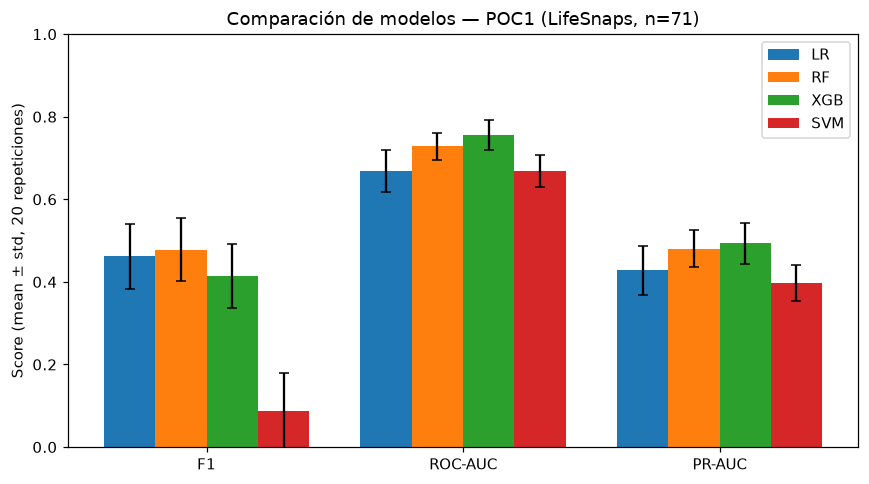

In [27]:
fig, ax = plt.subplots(figsize=(8, 4.5))
metrics_to_plot = ["f1_mean", "roc_auc_mean", "pr_auc_mean"]
labels = ["F1", "ROC-AUC", "PR-AUC"]
x = np.arange(len(labels))
width = 0.2

models_to_plot = [("LR", lr_stats), ("RF", rf_stats), ("XGB", xgb_stats), ("SVM", svm_stats)]
for i, (name, stats) in enumerate(models_to_plot):
    values = [stats[m] for m in metrics_to_plot]
    errors = [stats[m.replace("_mean", "_std")] for m in metrics_to_plot]
    offset = (i - (len(models_to_plot) - 1) / 2) * width
    ax.bar(x + offset, values, width, yerr=errors, capsize=3, label=name)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Score (mean ± std, 20 repeticiones)")
ax.set_title("Comparación de modelos — POC1 (LifeSnaps, n=71)")
ax.legend()
plt.tight_layout()
plt.show()


## Feature importance del modelo elegido (RF): Gini vs. Permutation

Gini importance (`feature_importances_` nativo de sklearn) está sesgada a favor de variables
continuas de alta cardinalidad. Se compara contra permutation importance (scoring=ROC-AUC) para
ver si el "factor ganador" es el mismo con ambos métodos. Ambas se promedian sobre las mismas
20 semillas para ser consistentes con la metodología del resto del notebook.

In [28]:
gini_sum = np.zeros(X.shape[1])
perm_sum = np.zeros(X.shape[1])

for r in range(N_REPEATS):
    rf = make_rf(RANDOM_STATE + r)
    rf.fit(X, y)
    gini_sum += rf.feature_importances_
    perm_result = permutation_importance(
        rf, X, y, scoring="roc_auc", n_repeats=10, random_state=RANDOM_STATE + r
    )
    perm_sum += perm_result.importances_mean

gini_importances = pd.Series(gini_sum / N_REPEATS, index=feature_cols).sort_values(ascending=False)
perm_importances = pd.Series(perm_sum / N_REPEATS, index=feature_cols).sort_values(ascending=False)

print(f"Top feature (Gini):        {gini_importances.index[0]}")
print(f"Top feature (Permutation): {perm_importances.index[0]}")
print("COINCIDEN" if gini_importances.index[0] == perm_importances.index[0] else "NO COINCIDEN — el top-1 cambia según el método (ver nota abajo)")


Top feature (Gini):        minutesAwake_std
Top feature (Permutation): sedentary_minutes_mean
NO COINCIDEN — el top-1 cambia según el método (ver nota abajo)


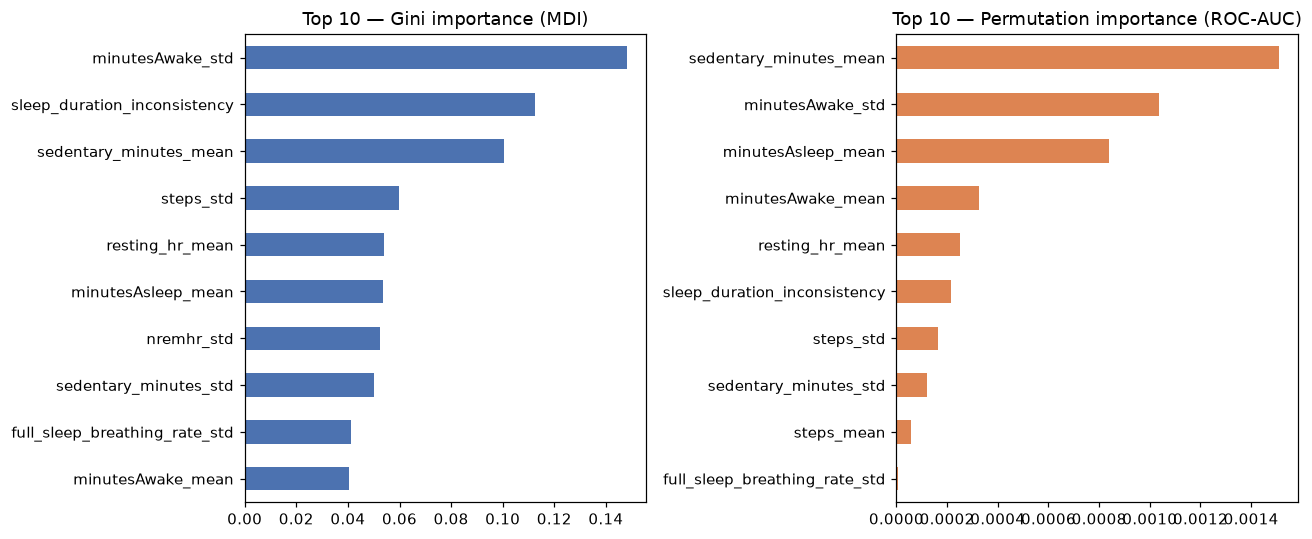

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
gini_importances.head(10).sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_title("Top 10 — Gini importance (MDI)")
perm_importances.head(10).sort_values().plot.barh(ax=axes[1], color="#DD8452")
axes[1].set_title("Top 10 — Permutation importance (ROC-AUC)")
plt.tight_layout()
plt.show()


**Nota de interpretación:** el "ganador" exacto puede cambiar entre métodos porque los
valores de permutation importance suelen estar muy cerca entre sí en el top-3/4 — la diferencia
es marginal, no una señal fuerte de que un factor domine sobre los demás. Lo estable en ambos
rankings es el mismo grupo: inconsistencia de sueño/vigilia noche a noche + inactividad.
**Por eso el payload que recibe el LLM manda el ranking completo, no solo el top-1** — para que
hable de "factores principales" en plural.

## Payload de ejemplo — lo que ML1 le entregaría al LLM

Estructura real que consumiría el módulo de recomendaciones (LLM), por estudiante: nivel y
probabilidad de riesgo, factor principal, y el ranking completo de importancia.

In [30]:
rf_final = make_rf(RANDOM_STATE)
rf_final.fit(X, y)
risk_proba = rf_final.predict_proba(X)[:, 1]

importances_sorted = gini_importances
sample_payloads = []
for i, row in person_df.reset_index(drop=True).iterrows():
    top_factor = importances_sorted.index[0]
    sample_payloads.append({
        "student_id": row[COL_ID],
        "risk_level": "alto" if risk_proba[i] >= 0.5 else "bajo",
        "risk_probability": round(float(risk_proba[i]), 3),
        "top_risk_factor": top_factor,
        "feature_importance_ranked": [
            {"feature": f, "importance": round(float(v), 4)}
            for f, v in importances_sorted.items()
        ][:5],
    })

print(json.dumps(sample_payloads[0], indent=2, ensure_ascii=False))


{
  "student_id": "621e2e8e67b776a24055b564",
  "risk_level": "bajo",
  "risk_probability": 0.087,
  "top_risk_factor": "minutesAwake_std",
  "feature_importance_ranked": [
    {
      "feature": "minutesAwake_std",
      "importance": 0.1482
    },
    {
      "feature": "sleep_duration_inconsistency",
      "importance": 0.1124
    },
    {
      "feature": "sedentary_minutes_mean",
      "importance": 0.1003
    },
    {
      "feature": "steps_std",
      "importance": 0.0598
    },
    {
      "feature": "resting_hr_mean",
      "importance": 0.0541
    }
  ]
}


## Conclusiones y limitaciones honestas

- El modelo aprende una señal real (ROC-AUC muy por encima de 0.5), pero está lejos de
  perfecto — con n=71 y una etiqueta que ya sabemos que es aproximada, es el resultado esperable.
- **La etiqueta es un proxy** (sleep score de Fitbit), no el PSQI real. Este es el punto más
  importante de todo el notebook: **estos números no son el resultado final del TI**.
- n=71 con mucho dato faltante real (SpO2 falta en ~83% de las filas, sleep score en ~75%) —
  se imputa con mediana poblacional, documentado como limitación.
- No existe en la literatura revisada un benchmark directamente comparable (n similar, riesgo
  por persona en universitarios, Random Forest) — el detalle de 7 estudios revisados y por qué
  ninguno es comparable está en `poc1/README.md`, sección "Contexto de benchmark en la literatura".
- Se probó agregar variables psicológicas (STAI/PANAS) de las encuestas de LifeSnaps — parecían
  mejorar el F1 con una sola semilla, pero bajo evaluación repetida esa mejora era ruido. Se
  descartaron del pipeline oficial (ver `poc1/checks/robustness_check.py`).
- **Deep Learning se descartó con respaldo de literatura, no por suposición:** se le preguntó
  directamente a las fuentes de la tesis (vía NotebookLM) y ninguna usa o recomienda DL para
  este tipo de dato (tabular, agregado por persona, n<200) — los usos de DL en la literatura del
  dominio son sobre señales crudas época-por-época, otra tarea distinta. La misma consulta señaló
  a SVM como el modelo clásico pendiente (Aziz et al. 2025), por eso se agregó arriba.


## Próximos pasos

1. **Reemplazar la etiqueta proxy por el PSQI real** en cuanto existan los datos de la encuesta
   (Capa A, n≥50) y volver a correr todo este notebook.
2. La literatura también menciona SVM y Regresión Logística como los modelos clásicos más usados
   en el dominio (Aziz et al. 2025) — ambos ya están cubiertos en la comparación de arriba. Si en
   el futuro surge una fuente nueva que respalde otro método (o Deep Learning, con una muestra
   más grande), se agrega siguiendo el mismo protocolo (Repeated Stratified 5-Fold × 20).
